**Expt 13 - Exponential Smoothing - Forecasting Problem**

   Week  Demand  Forecast (α=0.1)  Forecast (α=0.6)
0     1   820.0        820.000000        820.000000
1     2   775.0        820.000000        820.000000
2     3   680.0        815.500000        793.000000
3     4   655.0        801.950000        725.200000
4     5   750.0        787.255000        683.080000
5     6   802.0        783.529500        723.232000
6     7   798.0        785.376550        770.492800
7     8   689.0        786.638895        786.997120
8     9   775.0        776.875006        728.198848
9    10     NaN        776.875006        728.198848


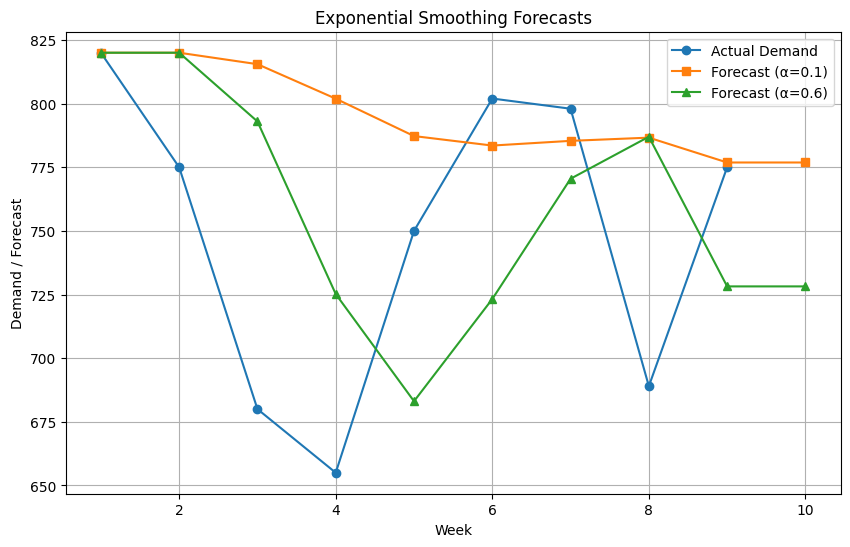

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Weekly demand data
weeks = list(range(1, 11))
demand = [820, 775, 680, 655, 750, 802, 798, 689, 775, None]

# Exponential smoothing function
def exponential_smoothing(demand, alpha):
    forecasts = [demand[0]]  # F1 = D1
    for t in range(1, len(demand)):
        if demand[t] is None:  # If demand missing (like week 10), continue forecasting
            forecasts.append(forecasts[-1])
        else:
            ft = alpha * demand[t-1] + (1 - alpha) * forecasts[-1]
            forecasts.append(ft)
    return forecasts

# Forecasts for alpha = 0.1 and 0.6
alpha_01 = exponential_smoothing(demand, 0.10)
alpha_06 = exponential_smoothing(demand, 0.60)

# DataFrame for results
df = pd.DataFrame({
    "Week": weeks,
    "Demand": demand,
    "Forecast (α=0.1)": alpha_01,
    "Forecast (α=0.6)": alpha_06
})

print(df)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(weeks, demand, marker='o', label="Actual Demand")
plt.plot(weeks, alpha_01, marker='s', label="Forecast (α=0.1)")
plt.plot(weeks, alpha_06, marker='^', label="Forecast (α=0.6)")
plt.xlabel("Week")
plt.ylabel("Demand / Forecast")
plt.title("Exponential Smoothing Forecasts")
plt.legend()
plt.grid(True)
plt.show()
